# Drift combinado (covariate + concept) × Compatibilidad Stage1↔Stage2 (Physionet)

Extiende `compatibility_concept_drift.ipynb` (que aisló concept drift puro) al escenario que quedó
como próximo paso: **covariate y concept drift simultáneos**, sobre los mismos signos vitales y a la
misma severidad. Pregunta concreta que motiva este notebook (`plan/plan_semanal_pfc2.md`, Gap 1):

> ¿Hace falta A4 completa (reajustar Stage 1 *y* Stage 2), o basta con una variante más barata —
> corregir `X` hacia la referencia (como A2c) y solo reentrenar Stage 2 (como A3) — sin tocar Stage 1?

**Cómo se combina el drift:** para cada severidad, primero se aplica covariate shift (`DriftInjector`,
mezcla Beta por variable — igual que en `physionet_drift_injector.ipynb`) sobre los signos vitales, y
**sobre ese resultado ya desplazado** se aplica el concept drift (`ConceptDriftInjector`,
`logit_reweight_recentered`) para reetiquetar `Y`. Así la relación `Y|X` se evalúa exactamente sobre
los valores de `X` que el pipeline vería en producción bajo ambos efectos a la vez — no son dos
mundos independientes que luego se promedian.

**Acciones comparadas:** A1 (nada), A2 (refit Stage 1), A2c (corrección hacia referencia), A3 (refit
Stage 2), A4 (refit ambos), y **A2c+A3** (corrección hacia referencia + refit solo Stage 2 — la
alternativa barata que se quiere contrastar contra A4).

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from darl.data.get_dataset import load_dataset
from darl.drift import DriftInjector, ConceptDriftInjector
from darl.evaluation import ks_stat, psi_numeric
from darl.pipeline import fit_stage1, apply_stage1
from darl.actions.selective_update import (
    eval_metrics, fit_reference_quantile_map, apply_reference_quantile_map,
)

SEED = 42
np.random.seed(SEED)

VITALS = ["HR", "SBP", "MAP", "Resp", "Temp"]
LABEL_COL = "SepsisLabel"
THRESHOLD = 0.5
SAMPLE_SIZE = 50_000
SEVERITIES = [0.0, 0.2, 0.5, 0.8, 1.0, 1.2]
CONCEPT_MECHANISM = "logit_reweight_recentered"  # Physionet needs the recentered variant (see compatibility_concept_drift.ipynb)
NUM_CFG = {"HR": "high", "SBP": "low", "MAP": "low", "Resp": "high", "Temp": "extreme"}

print("Imports OK")

C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Imports OK


### Nota — sustitución de Stage 2

Igual que en `compatibility_concept_drift.ipynb`: `darl.pipeline.make_logreg` (saga + `class_weight="balanced"`)
combinado con la salida de `fit_stage1` produce un modelo degenerado (bug preexistente, ajeno al drift).
Se reusan las mismas versiones locales de A1–A4 con `LogisticRegression()` simple, más una nueva acción
híbrida `A2c+A3`.

In [2]:
def run_a1_local(df_drifted_target, qt, imputer, scaler, model, vitals, numeric_cols, label_col, threshold):
    df_t = apply_stage1(df_drifted_target, qt, imputer, scaler, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), 0.0


def run_a2_local(df_drifted_target, df_drifted_train, model, vitals, numeric_cols, label_col, threshold, seed=42):
    t0 = time.perf_counter()
    qt_new, imputer_new, scaler_new = fit_stage1(df_drifted_train, vitals, numeric_cols, seed)
    t_fit = time.perf_counter() - t0
    df_t = apply_stage1(df_drifted_target, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), t_fit


def run_a2c_local(df_drifted_target, df_drifted_train, df_reference_train, qt_ref, imputer_ref, scaler_ref,
                  model, vitals, numeric_cols, label_col, threshold):
    t0 = time.perf_counter()
    qmap = fit_reference_quantile_map(df_drifted_train, df_reference_train, vitals)
    df_corrected_target = apply_reference_quantile_map(df_drifted_target, qmap)
    t_update = time.perf_counter() - t0
    df_t = apply_stage1(df_corrected_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), t_update


def run_a3_local(df_drifted_target, df_drifted_train, qt_ref, imputer_ref, scaler_ref,
                 vitals, numeric_cols, label_col, threshold, seed=42):
    df_tr_t = apply_stage1(df_drifted_train, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values
    model_new = LogisticRegression(max_iter=1000)
    t0 = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_fit = time.perf_counter() - t0
    df_t = apply_stage1(df_drifted_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model_new, x, y, threshold), t_fit


def run_a4_local(df_drifted_target, df_drifted_train, vitals, numeric_cols, label_col, threshold, seed=42):
    t0_stage1 = time.perf_counter()
    qt_new, imputer_new, scaler_new = fit_stage1(df_drifted_train, vitals, numeric_cols, seed)
    t_stage1 = time.perf_counter() - t0_stage1
    df_tr_t = apply_stage1(df_drifted_train, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values
    model_new = LogisticRegression(max_iter=1000)
    t0_model = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_model = time.perf_counter() - t0_model
    df_t = apply_stage1(df_drifted_target, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model_new, x, y, threshold), t_stage1 + t_model


def run_a2c_plus_a3_local(df_drifted_target, df_drifted_train, df_reference_train, qt_ref, imputer_ref, scaler_ref,
                          vitals, numeric_cols, label_col, threshold, seed=42):
    # Cheap alternative to A4: correct X toward reference (A2c-style), keep Stage 1 frozen,
    # but retrain Stage 2 (A3-style) on the corrected X + drifted Y.
    t0 = time.perf_counter()
    qmap = fit_reference_quantile_map(df_drifted_train, df_reference_train, vitals)
    df_corrected_train = apply_reference_quantile_map(df_drifted_train, qmap)
    df_corrected_target = apply_reference_quantile_map(df_drifted_target, qmap)
    t_correct = time.perf_counter() - t0

    df_tr_t = apply_stage1(df_corrected_train, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values  # X corrected, but the label itself is still the drifted one

    model_new = LogisticRegression(max_iter=1000)
    t0_model = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_model = time.perf_counter() - t0_model

    df_t = apply_stage1(df_corrected_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    metrics = eval_metrics(model_new, x, y, threshold)
    return metrics, t_correct + t_model

## 1. Carga del dataset y muestreo del set de entrenamiento

In [3]:
dset = load_dataset("physionet")
X_train, y_train, _, _ = dset.get_pandas(split="train")
X_target, y_target, _, _ = dset.get_pandas(split="id_test")

df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values
df_target = X_target.copy()
df_target[LABEL_COL] = y_target.values

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(df_train), size=SAMPLE_SIZE, replace=False)
df_train_sample = df_train.iloc[sample_idx].reset_index(drop=True)

print(f"Train (muestra) : {df_train_sample.shape}, prevalencia {df_train_sample[LABEL_COL].mean():.4f}")
print(f"Target (id_test): {df_target.shape}, prevalencia {df_target[LABEL_COL].mean():.4f}")

Train (muestra) : (50000, 41), prevalencia 0.0115
Target (id_test): (140288, 41), prevalencia 0.0120


## 2. Pipeline de referencia e inyectores (covariate + concept)

In [4]:
qt_ref, imputer_ref, scaler_ref = fit_stage1(df_train_sample, VITALS, VITALS, seed=SEED)

df_train_stage1 = apply_stage1(df_train_sample, qt_ref, imputer_ref, scaler_ref, VITALS, VITALS)
model_ref = LogisticRegression(max_iter=1000)
model_ref.fit(df_train_stage1[VITALS].values, df_train_sample[LABEL_COL].values)

baseline = eval_metrics(
    model_ref, apply_stage1(df_target, qt_ref, imputer_ref, scaler_ref, VITALS, VITALS)[VITALS].values,
    df_target[LABEL_COL].values, THRESHOLD,
)
print("Baseline (sin drift):", baseline)

cov_inj = DriftInjector(random_state=SEED)
cov_inj.fit(df_train_sample, numeric_cols=VITALS)

concept_inj = ConceptDriftInjector(random_state=SEED)
concept_inj.fit(df_train_sample, target_vars=VITALS, label_col=LABEL_COL)
print("Inyectores listos")

Baseline (sin drift): {'auc': 0.6169846090148248, 'aupr': 0.021977186145628762, 'f1': 0.0}
Inyectores listos


## 3. Generar drift combinado y ejecutar las 6 acciones, por severidad

Para cada severidad: primero covariate shift sobre `X`, luego concept drift (relabeling de `Y`)
evaluado sobre esos mismos valores de `X` ya desplazados.

In [5]:
results = []
for sev in SEVERITIES:
    df_cov_train, _ = cov_inj.transform(df_train_sample, drift_severity=min(sev, 1.0), drift_type="covariate", numeric_drift_config=NUM_CFG)
    df_combined_train, _ = concept_inj.transform(df_cov_train, severity=sev, mechanism=CONCEPT_MECHANISM)

    df_cov_target, _ = cov_inj.transform(df_target, drift_severity=min(sev, 1.0), drift_type="covariate", numeric_drift_config=NUM_CFG)
    df_combined_target, _ = concept_inj.transform(df_cov_target, severity=sev, mechanism=CONCEPT_MECHANISM)

    m1, t1 = run_a1_local(df_combined_target, qt_ref, imputer_ref, scaler_ref, model_ref, VITALS, VITALS, LABEL_COL, THRESHOLD)
    m2, t2 = run_a2_local(df_combined_target, df_combined_train, model_ref, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED)
    m2c, t2c = run_a2c_local(
        df_combined_target, df_combined_train, df_train_sample,
        qt_ref, imputer_ref, scaler_ref, model_ref, VITALS, VITALS, LABEL_COL, THRESHOLD,
    )
    m3, t3 = run_a3_local(df_combined_target, df_combined_train, qt_ref, imputer_ref, scaler_ref, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED)
    m4, t4 = run_a4_local(df_combined_target, df_combined_train, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED)
    m5, t5 = run_a2c_plus_a3_local(
        df_combined_target, df_combined_train, df_train_sample,
        qt_ref, imputer_ref, scaler_ref, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED,
    )

    for action, metrics, fit_time in [
        ("A1_frozen", m1, t1), ("A2_refit_stage1", m2, t2), ("A2c_corrective", m2c, t2c),
        ("A3_refit_stage2", m3, t3), ("A4_refit_both", m4, t4), ("A2c_plus_A3", m5, t5),
    ]:
        results.append({"severity": sev, "action": action, "fit_time_s": fit_time, **metrics})

df_results = pd.DataFrame(results)
df_auc_pivot = df_results.pivot(index="severity", columns="action", values="auc")
df_auc_pivot

action,A1_frozen,A2_refit_stage1,A2c_corrective,A2c_plus_A3,A3_refit_stage2,A4_refit_both
severity,,,,,,
0.0,0.617370,0.616985,0.616985,0.616985,0.618660,0.616985
0.2,0.575664,0.577881,0.578187,0.580165,0.571008,0.578918
0.5,0.524757,0.526602,0.526181,0.525535,0.518879,0.526008
0.8,0.473535,0.482223,0.482184,0.515390,0.528078,0.514728
1.0,0.413708,0.461971,0.461539,0.539245,0.590501,0.538371
1.2,0.336349,0.456904,0.455309,0.551421,0.672344,0.549827


## 4. Costo — tiempo de ajuste por acción

In [6]:
df_time_pivot = df_results.pivot(index="severity", columns="action", values="fit_time_s")
df_time_pivot[["A4_refit_both", "A2c_plus_A3"]]

action,A4_refit_both,A2c_plus_A3
severity,,
0.0,0.107635,0.115131
0.2,0.107487,0.107973
0.5,0.106643,0.124026
0.8,0.105566,0.112795
1.0,0.105469,0.112601
1.2,0.103976,0.114993


## 5. Gráfica — AUC por acción y severidad

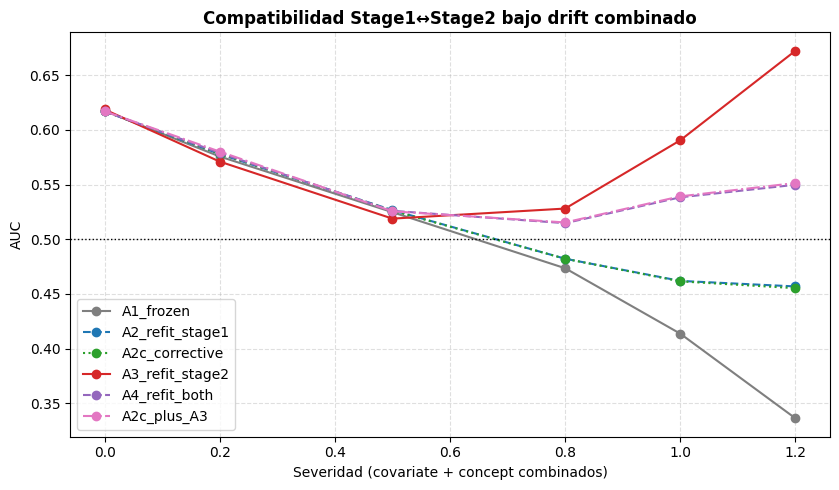

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
styles = {
    "A1_frozen": ("#7f7f7f", "-"),
    "A2_refit_stage1": ("#1f77b4", "--"),
    "A2c_corrective": ("#2ca02c", ":"),
    "A3_refit_stage2": ("#d62728", "-"),
    "A4_refit_both": ("#9467bd", "--"),
    "A2c_plus_A3": ("#e377c2", "-."),
}
for action, (color, ls) in styles.items():
    ax.plot(df_auc_pivot.index, df_auc_pivot[action], marker="o", label=action, color=color, linestyle=ls)
ax.axhline(0.5, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Severidad (covariate + concept combinados)")
ax.set_ylabel("AUC")
ax.set_title("Compatibilidad Stage1↔Stage2 bajo drift combinado", fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Validación — bajo drift combinado, `P(X)` sí debe moverse (a diferencia del notebook de concept drift puro)

In [8]:
stability_rows = []
for sev in SEVERITIES:
    df_cov_target, _ = cov_inj.transform(df_target, drift_severity=min(sev, 1.0), drift_type="covariate", numeric_drift_config=NUM_CFG)
    df_combined_target, _ = concept_inj.transform(df_cov_target, severity=sev, mechanism=CONCEPT_MECHANISM)
    for col in VITALS:
        ks = ks_stat(df_target[col], df_combined_target[col])
        psi = psi_numeric(df_target[col], df_combined_target[col])
        stability_rows.append({"severity": sev, "variable": col, "ks_stat": ks["ks_stat"], "psi": psi})

df_stability = pd.DataFrame(stability_rows)
df_stability.pivot(index="variable", columns="severity", values="ks_stat")

severity,0.0,0.2,0.5,0.8,1.0,1.2
variable,,,,,,
HR,0.033282,0.154166,0.383352,0.614268,0.769068,0.770322
MAP,0.024759,0.070120,0.174703,0.279801,0.349037,0.348309
Resp,0.108714,0.185718,0.467073,0.747303,0.930300,0.929868
SBP,0.017936,0.107056,0.252268,0.397230,0.498083,0.500619
Temp,0.053232,0.116710,0.268921,0.426846,0.530716,0.529451


## 7. Guardar artefactos

In [9]:
from darl.utils import find_project_root

OUT_DIR = find_project_root() / "outputs" / "metrics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_results.to_csv(OUT_DIR / "gap1_gap2_compatibility_combined_drift_physionet.csv", index=False)
df_stability.to_csv(OUT_DIR / "gap1_gap2_combined_x_stability_physionet.csv", index=False)

print("Artefactos guardados en", OUT_DIR)

Artefactos guardados en C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\outputs\metrics


## 8. Conclusiones

- Bajo drift combinado, `P(X)` **sí** se mueve de forma ordenada con la severidad (KS hasta 0.93 en
  `Resp` a severidad 1.2) — a diferencia del notebook de concept drift puro, donde KS/PSI eran
  exactamente 0. Confirma que aquí ambos mecanismos están activos a la vez.
- **A1 degrada más que en el escenario de concept drift puro** (cae a 0.336 en vez de 0.346), porque
  ahora también absorbe el covariate shift sin corregirlo.
- **A2/A2c sí ayudan un poco aquí** (a diferencia de concept drift puro, donde eran idénticas a A1):
  en severidad 1.2 llegan a ≈0.456 contra 0.336 de A1 — consistente con que corrigen la parte de
  covariate shift, aunque no la parte conceptual.

### El resultado que contradice la hipótesis inicial

La pregunta que motivó este notebook era "¿hace falta A4 completa, o basta con A2c+A3 (más barata)?".
Los datos dicen algo distinto a lo que ambas opciones predecían:

| Severidad | A2c+A3 | A3 (solo) | A4 (completa) |
|---|---|---|---|
| 0.8 | 0.515 | **0.528** | 0.515 |
| 1.0 | 0.539 | **0.591** | 0.538 |
| 1.2 | 0.551 | **0.672** | 0.550 |

**A3 sola —sin tocar Stage 1 en absoluto— gana a las dos alternativas que sí lo tocan** (A2c+A3 y A4),
y por un margen creciente con la severidad. Reajustar o corregir Stage 1 no solo no ayuda aquí: activamente
perjudica un poco frente a dejarlo exactamente como se entrenó originalmente. Una lectura plausible:
`fit_stage1` usa un `QuantileTransformer` que renormaliza cada variable a su propio rango de percentiles
dentro de los datos que recibe — al reajustarlo (o corregirlo) sobre los datos ya desplazados, cambia el
sistema de referencia de cada variable de una corrida a otra, y ese cambio de referencia parece estorbar
más de lo que ayuda una vez que Stage 2 se reentrena de todas formas para adaptarse a lo que sea que
Stage 1 le entregue.

**Tampoco se sostiene el argumento de costo:** A4 y A2c+A3 tardan prácticamente lo mismo en ajustarse
(~0.10–0.12s, sección 4) — `fit_stage1` es barato en sí mismo, así que "ahorrar" el reajuste de Stage 1
no reduce el costo de forma apreciable en este caso.

**Conclusión revisada:** en este escenario (Physionet, `logit_reweight_recentered` + covariate Beta-mix),
la acción recomendada bajo drift combinado es **A3** (mantener Stage 1 congelado tal como se desplegó,
reentrenar solo Stage 2) — no A4 ni la variante híbrida A2c+A3 que se propuso como alternativa barata.
Esto es un hallazgo empírico específico de esta configuración, no una regla general: valdría la pena
repetirlo con otra dirección/magnitud de covariate shift antes de generalizar la recomendación.

**Próximos pasos:** repetir con `diabetes_readmission`; verificar si el resultado "A3 sola gana" se
sostiene con otras configuraciones de `numeric_drift_config` (p. ej. covariate shift más leve, o en
variables distintas a las que domina la relación de concept drift); si se confirma, usar A3 como acción
por defecto en el entorno de RL de Jeffrey (Gap 3) en vez de A4.